# 02 — Anomaly Detection (ROAD)

The pipeline runs across all throughput limitations in `THROUGHPUT_LIMS`.
Each section is a separate cell — you can re-run any phase independently
without restarting from scratch.

| Section | Description |
|---|---|
| 0 | Imports & configuration |
| 1 | Load data |
| 2 | Filter & prepare per limitation |
| 3 | Detector benchmark |
| 4 | Normality model + anomaly detection |
| 5 | Explainability (SHAP) |
| 6 | SAFE AI metrics (RGA / RGE / RGR) |
| 7 | ROAD feature ranking |
| 8 | Decision tree |

**Input:** `output/data_clean3.csv`  
**Outputs:** `output/decision_trees/lim_*.png`

## 0. Imports & configuration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn import tree
import graphviz

from data_lab.config import (
    OUT_DATASETS, DATA_PATH, TREE_DIR,
    TARGET, THROUGHPUT_LIMS,
    DT_MAX_DEPTH, DT_MIN_SAMPLES, DT_CROSS_VAL,
)
from data_lab.preprocessing_functions import norm_cols
from data_lab.detection import mad_outliers, benchmark_detectors, score_table, double_mad_outliers
from data_lab.explainability import (
    prepare_training_split,
    fit_normality_model,
    predict_target,
    compute_residuals,
    detect_residual_anomalies,
    compute_shap_values,
    rank_features_by_mean_abs_shap,
)
from data_lab.tree_utils import DTClassifier
from data_lab.road import cluster_anomaly_support_optimal
from data_lab.safeai import safeai_summary
from data_lab.plot_functions import (
    plot_shap_summary,
    plot_xgb_importance,
    plot_road_ranking,
    plot_prediction_diagnostics,
)

TREE_DIR.mkdir(parents=True, exist_ok=True)

# shared state across cells — populated incrementally
results = {lim: {} for lim in THROUGHPUT_LIMS}
print(f"Initialised results for {len(THROUGHPUT_LIMS)} limitations: {THROUGHPUT_LIMS}")

Initialised results for 6 limitations: ['1000kbit', '2000kbit', '5000kbit', '10000kbit', '20000kbit', '50000kbit']


## 1. Load data

In [2]:
data_raw = norm_cols(
    pd.read_csv(OUT_DATASETS / "data_clean3.csv", encoding="ISO-8859-1", low_memory=False)
)
print(f"Loaded: {data_raw.shape[0]} rows, {data_raw.shape[1]} columns")
data_raw.head()

Loaded: 7220 rows, 123 columns


,dl.latency.value,dl.retransmission.value,bw.std,minrtt.min,minrtt.std,pacinggain.min,pacinggain.std,pacinggain.q10,pacinggain.q90,cwndgain.min,...,rcvooopack.max,rcvooopack.median,rcvooopack.q10,rcvooopack.q25,rcvooopack.q75,dl.throughput.value,limitation,throughputlim,latencylim,packetlosslim
0,4.975,0.015771,3.088844e+06,4975,1.775957,192,29.512514,256.0,320.0,512,...,0,0.0,0.0,0.0,0.0,593.277440,NaN,NaN,NaN,NaN
1,4.446,0.430338,5.833303e+06,4446,221.363562,192,93.765206,249.6,320.0,512,...,0,0.0,0.0,0.0,0.0,579.654536,NaN,NaN,NaN,NaN
2,6.795,0.000000,1.008394e+05,6795,685.048690,192,111.340018,192.0,320.0,512,...,0,0.0,0.0,0.0,0.0,18.040134,Throughput,20000kbit,NaN,NaN
3,4.953,0.312673,2.650679e+06,4953,2.884697,192,36.963555,236.8,320.0,512,...,0,0.0,0.0,0.0,0.0,584.629354,NaN,NaN,NaN,NaN
4,965.102,0.000000,1.731948e+05,965102,9403.079352,739,0.000000,739.0,739.0,739,...,0,0.0,0.0,0.0,0.0,7.570025,Latency,NaN,500ms,NaN


## 2. Filter & prepare

For each limitation, select the relevant rows, apply log-transform to the KPI,
and compute the MAD outlier mask and contamination rate.

In [4]:
for lim in THROUGHPUT_LIMS:
    lim_mask = data_raw["limitation"].isna() | (data_raw["throughputlim"] == lim)
    data_lim = data_raw.loc[lim_mask].copy()

    outliers_real = (data_lim["throughputlim"] == lim)

    pos_mask = data_lim[TARGET] > 0
    data_lim = data_lim.loc[pos_mask].copy()
    outliers_real = outliers_real.loc[data_lim.index]

    X_lim = data_lim.select_dtypes(include="number").drop(
        columns=["throughputlim"],
        errors="ignore"
    ).copy()

    X_lim[TARGET] = np.log10(X_lim[TARGET])

    outliers_mad = mad_outliers(X_lim[TARGET], threshold=5)
    outliers_double_mad = double_mad_outliers(X_lim[TARGET], threshold=5)

    contamination = float(outliers_real.mean())

    results[lim].update({
        "X_lim": X_lim,
        "outliers_real": outliers_real,
        "outliers_mad": outliers_mad,
        "outliers_double_mad": outliers_double_mad,
        "contamination": contamination,
    })

    print(
        f"{lim:12s} — samples: {len(X_lim):4d} | "
        f"contamination: {contamination:.3f} | "
        f"MAD: {int(outliers_mad.sum()):4d} | "
        f"Double MAD: {int(outliers_double_mad.sum()):4d}"
    )

1000kbit     — samples: 4446 | contamination: 0.048 | MAD:  317 | Double MAD:  275
2000kbit     — samples: 4443 | contamination: 0.047 | MAD:  314 | Double MAD:  273
5000kbit     — samples: 4444 | contamination: 0.048 | MAD:  315 | Double MAD:  275
10000kbit    — samples: 4448 | contamination: 0.049 | MAD:  319 | Double MAD:  277
20000kbit    — samples: 4450 | contamination: 0.049 | MAD:  320 | Double MAD:  279
50000kbit    — samples: 4450 | contamination: 0.049 | MAD:  320 | Double MAD:  279


In [5]:
comparison_rows = []

for lim in THROUGHPUT_LIMS:
    r = results[lim]

    mad_count = int(r["outliers_mad"].sum())
    double_mad_count = int(r["outliers_double_mad"].sum())
    total = len(r["X_lim"])

    comparison_rows.append({
        "throughputlim": lim,
        "samples": total,
        "real_contamination": float(r["contamination"]),
        "mad_outliers": mad_count,
        "mad_ratio": mad_count / total,
        "double_mad_outliers": double_mad_count,
        "double_mad_ratio": double_mad_count / total,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,throughputlim,samples,real_contamination,mad_outliers,mad_ratio,double_mad_outliers,double_mad_ratio
0,1000kbit,4446,0.048133,317,0.071300,275,0.061853
1,2000kbit,4443,0.047490,314,0.070673,273,0.061445
2,5000kbit,4444,0.047705,315,0.070882,275,0.061881
3,10000kbit,4448,0.048561,319,0.071718,277,0.062275
4,20000kbit,4450,0.048989,320,0.071910,279,0.062697
5,50000kbit,4450,0.048989,320,0.071910,279,0.062697


In [6]:
overlap_rows = []

for lim in THROUGHPUT_LIMS:
    mad_mask = results[lim]["outliers_mad"]
    double_mad_mask = results[lim]["outliers_double_mad"]

    both = int((mad_mask & double_mad_mask).sum())
    only_mad = int((mad_mask & ~double_mad_mask).sum())
    only_double_mad = int((~mad_mask & double_mad_mask).sum())

    overlap_rows.append({
        "throughputlim": lim,
        "both": both,
        "only_mad": only_mad,
        "only_double_mad": only_double_mad,
    })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df

,throughputlim,both,only_mad,only_double_mad
0,1000kbit,275,42,0
1,2000kbit,273,41,0
2,5000kbit,275,40,0
3,10000kbit,277,42,0
4,20000kbit,279,41,0
5,50000kbit,279,41,0


In [7]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

comparison_rows = []

for lim in THROUGHPUT_LIMS:
    real = results[lim]["outliers_real"].astype(bool)
    mad = results[lim]["outliers_mad"].astype(bool)
    double_mad = results[lim]["outliers_double_mad"].astype(bool)

    # MAD confusion matrix
    tn_mad, fp_mad, fn_mad, tp_mad = confusion_matrix(real, mad, labels=[False, True]).ravel()

    # Double MAD confusion matrix
    tn_dm, fp_dm, fn_dm, tp_dm = confusion_matrix(real, double_mad, labels=[False, True]).ravel()

    comparison_rows.append({
        "throughputlim": lim,
        "samples": len(real),
        "real_outliers": int(real.sum()),

        "mad_outliers": int(mad.sum()),
        "mad_tp": int(tp_mad),
        "mad_fp": int(fp_mad),
        "mad_fn": int(fn_mad),
        "mad_tn": int(tn_mad),
        "mad_precision": precision_score(real, mad, zero_division=0),
        "mad_recall": recall_score(real, mad, zero_division=0),
        "mad_f1": f1_score(real, mad, zero_division=0),

        "double_mad_outliers": int(double_mad.sum()),
        "double_mad_tp": int(tp_dm),
        "double_mad_fp": int(fp_dm),
        "double_mad_fn": int(fn_dm),
        "double_mad_tn": int(tn_dm),
        "double_mad_precision": precision_score(real, double_mad, zero_division=0),
        "double_mad_recall": recall_score(real, double_mad, zero_division=0),
        "double_mad_f1": f1_score(real, double_mad, zero_division=0),
    })

comparison_with_real_df = pd.DataFrame(comparison_rows)
comparison_with_real_df

,throughputlim,samples,real_outliers,mad_outliers,mad_tp,mad_fp,mad_fn,mad_tn,mad_precision,mad_recall,mad_f1,double_mad_outliers,double_mad_tp,double_mad_fp,double_mad_fn,double_mad_tn,double_mad_precision,double_mad_recall,double_mad_f1
0,1000kbit,4446,214,317,214,103,0,4129,0.675079,1.0,0.806026,275,214,61,0,4171,0.778182,1.0,0.875256
1,2000kbit,4443,211,314,211,103,0,4129,0.671975,1.0,0.803810,273,211,62,0,4170,0.772894,1.0,0.871901
2,5000kbit,4444,212,315,212,103,0,4129,0.673016,1.0,0.804554,275,212,63,0,4169,0.770909,1.0,0.870637
3,10000kbit,4448,216,319,216,103,0,4129,0.677116,1.0,0.807477,277,216,61,0,4171,0.779783,1.0,0.876268
4,20000kbit,4450,218,320,218,102,0,4130,0.681250,1.0,0.810409,279,218,61,0,4171,0.781362,1.0,0.877264
5,50000kbit,4450,218,320,218,102,0,4130,0.681250,1.0,0.810409,279,218,61,0,4171,0.781362,1.0,0.877264


In [8]:
overlap_real_rows = []

for lim in THROUGHPUT_LIMS:
    real = results[lim]["outliers_real"].astype(bool)
    mad = results[lim]["outliers_mad"].astype(bool)
    double_mad = results[lim]["outliers_double_mad"].astype(bool)

    mad_on_real = int((mad & real).sum())
    double_mad_on_real = int((double_mad & real).sum())
    both_on_real = int((mad & double_mad & real).sum())

    overlap_real_rows.append({
        "throughputlim": lim,
        "real_outliers": int(real.sum()),
        "mad_hits_on_real": mad_on_real,
        "double_mad_hits_on_real": double_mad_on_real,
        "both_hits_on_real": both_on_real,
        "only_mad_hits_on_real": int((mad & ~double_mad & real).sum()),
        "only_double_mad_hits_on_real": int((~mad & double_mad & real).sum()),
    })

overlap_real_df = pd.DataFrame(overlap_real_rows)
overlap_real_df

,throughputlim,real_outliers,mad_hits_on_real,double_mad_hits_on_real,both_hits_on_real,only_mad_hits_on_real,only_double_mad_hits_on_real
0,1000kbit,214,214,214,214,0,0
1,2000kbit,211,211,211,211,0,0
2,5000kbit,212,212,212,212,0,0
3,10000kbit,216,216,216,216,0,0
4,20000kbit,218,218,218,218,0,0
5,50000kbit,218,218,218,218,0,0


## 3. Detector benchmark

Fit 12 PyOD detectors and MAD against the ground-truth outlier labels.
Results are sorted by F1-score.

In [ ]:
for lim in THROUGHPUT_LIMS:
    r   = results[lim]
    X   = r["X_lim"]
    y   = r["outliers_real"]
    mad = r["outliers_mad"]

    comparison = benchmark_detectors(X, y, r["contamination"])
    mad_row    = {"method": "MAD", **score_table(y, mad.astype(int))}
    comparison = pd.concat(
        [comparison, pd.DataFrame([mad_row])], ignore_index=True
    ).sort_values("f1_score", ascending=False)

    results[lim]["comparison"] = comparison

    print(f"\n=== {lim} ===")
    print(comparison.to_string(index=False))
    print("-" * 65)

## 4. Normality model + anomaly detection

Train XGBoost on non-outlier samples, compute residuals, detect anomalies
via OneClassSVM on the residual distribution.

In [9]:
for lim in THROUGHPUT_LIMS:
    r = results[lim]
    X = r["X_lim"]

    outliers_for_training = r["outliers_double_mad"]

    X_train, y_train, X_all = prepare_training_split(
        X,
        outliers_for_training,
        target=TARGET
    )

    model = fit_normality_model(X_train, y_train)
    y_predicted = predict_target(model, X_all)
    residuals = compute_residuals(X.loc[X_all.index, TARGET], y_predicted)
    anomalies = pd.Series(detect_residual_anomalies(residuals), index=X_all.index)

    results[lim].update({
        "X_train": X_train,
        "y_train": y_train,
        "X_all": X_all,
        "model": model,
        "y_predicted": y_predicted,
        "residuals": residuals,
        "anomalies": anomalies,
    })

    print(
        f"{lim:12s} — train samples: {len(X_train):4d} | "
        f"residual anomalies: {int(anomalies.sum()):4d} / {len(anomalies)}"
    )

1000kbit     — train samples: 4171 | residual anomalies:  332 / 4446
2000kbit     — train samples: 4170 | residual anomalies:  323 / 4443
5000kbit     — train samples: 4169 | residual anomalies:  326 / 4444
10000kbit    — train samples: 4171 | residual anomalies:  334 / 4448
20000kbit    — train samples: 4171 | residual anomalies:  336 / 4450
50000kbit    — train samples: 4171 | residual anomalies:  336 / 4450


In [10]:
for lim in THROUGHPUT_LIMS:
    r   = results[lim]
    X   = r["X_lim"]
    mad = r["outliers_mad"]

    X_train, y_train, X_all = prepare_training_split(X, mad, target=TARGET)

    model       = fit_normality_model(X_train, y_train)
    y_predicted = predict_target(model, X_all)

    residuals_2d = compute_residuals(
        X.loc[X_all.index, TARGET],
        y_predicted
    )  # shape (n, 1)

    residuals_1d = residuals_2d.ravel()

    anomalies = pd.Series(
        detect_residual_anomalies(residuals_2d),
        index=X_all.index
    )

    print(f"\n=== {lim} ===")
    print("len(X)               =", len(X))
    print("mad anomalies        =", int(mad.sum()))
    print("mad anomaly ratio    =", float(mad.mean()))
    print("len(X_train)         =", len(X_train))
    print("len(X_all)           =", len(X_all))
    print("residuals mean       =", float(np.mean(residuals_1d)))
    print("residuals std        =", float(np.std(residuals_1d)))
    print("residuals median     =", float(np.median(residuals_1d)))
    print("residuals q95        =", float(np.quantile(residuals_1d, 0.95)))
    print("final anomalies      =", int(anomalies.sum()))
    print("final anomaly ratio  =", float(anomalies.mean()))


=== 1000kbit ===
len(X)               = 4446
mad anomalies        = 317
mad anomaly ratio    = 0.07130004498425552
len(X_train)         = 4129
len(X_all)           = 4446
residuals mean       = 0.13400486046822446
residuals std        = 0.591299895462298
residuals median     = 7.199283126246847e-05
residuals q95        = 0.08087861948293906
final anomalies      = 368
final anomaly ratio  = 0.0827710301394512

=== 2000kbit ===
len(X)               = 4443
mad anomalies        = 314
mad anomaly ratio    = 0.07067296871483232
len(X_train)         = 4129
len(X_all)           = 4443
residuals mean       = 0.11825693691309007
residuals std        = 0.5249701833653152
residuals median     = 6.812129808420053e-05
residuals q95        = 0.06227191722088613
final anomalies      = 365
final anomaly ratio  = 0.08215169930227324

=== 5000kbit ===
len(X)               = 4444
mad anomalies        = 315
mad anomaly ratio    = 0.07088208820882089
len(X_train)         = 4129
len(X_all)           = 4444


## 5. Explainability — SHAP

SHAP values quantify the marginal contribution of each feature to individual predictions.
The beeswarm plot shows both direction and magnitude of each feature's impact.


=== 1000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
dl.retransmission.value       0.007264
       dl.latency.value       0.001879
                 bw.std       0.001171
                rtt.std       0.001152
        lastackrecv.max       0.001022
             rttvar.q90       0.000944
        elapsedtime.min       0.000570
           busytime.max       0.000554
             minrtt.std       0.000548
             minrtt.min       0.000475


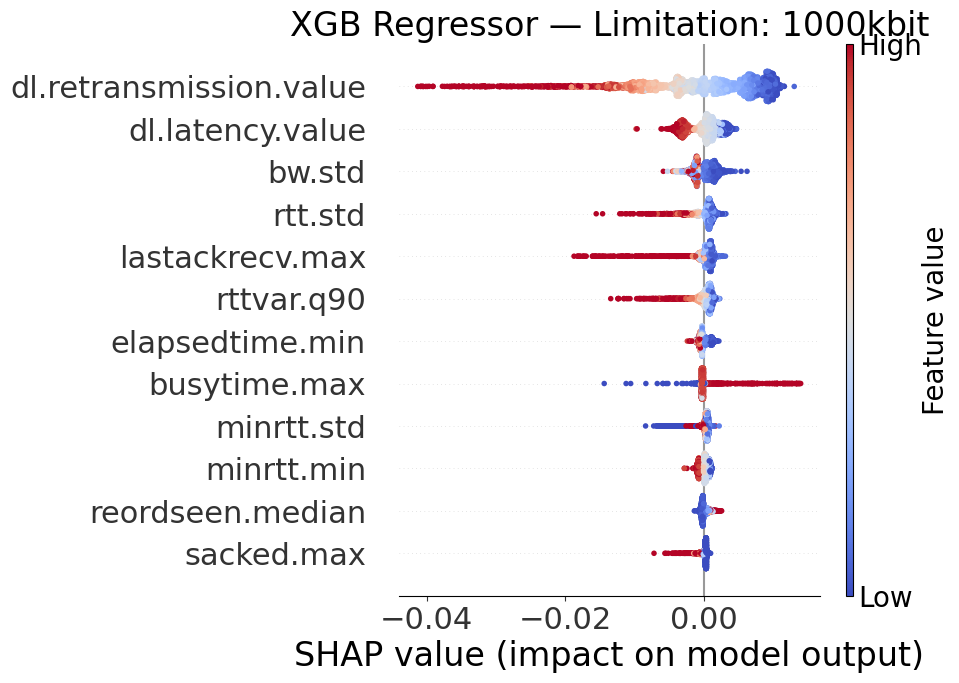

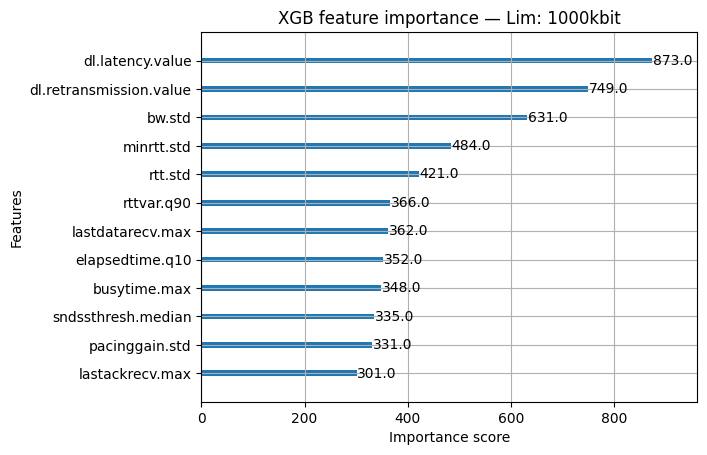

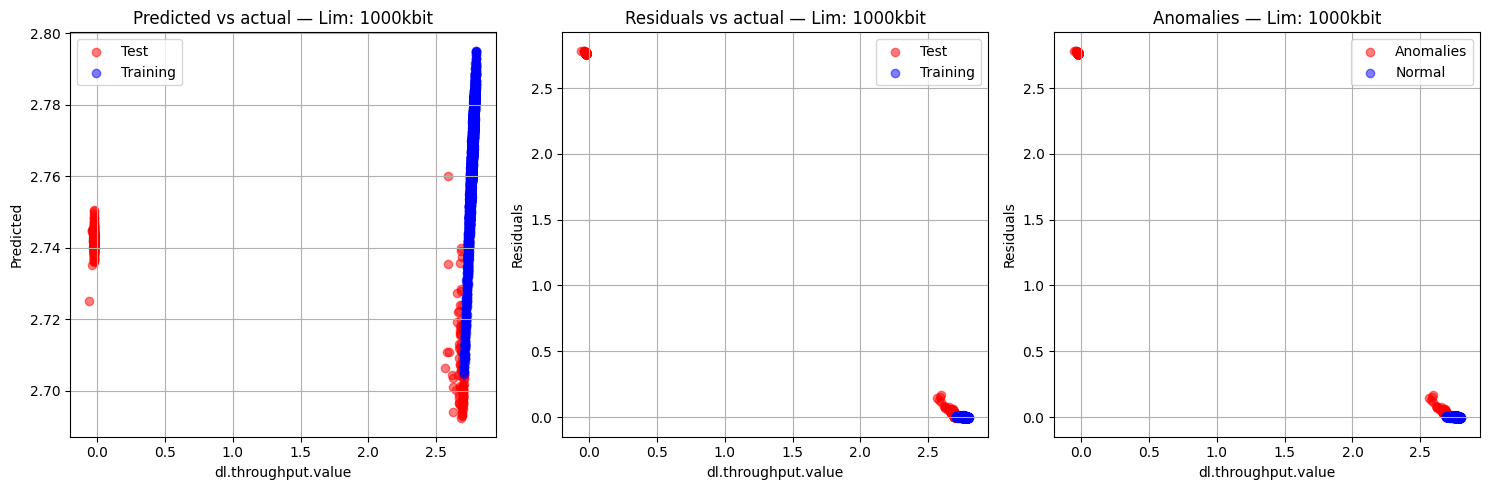


=== 2000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
dl.retransmission.value       0.007261
       dl.latency.value       0.001857
                rtt.std       0.001192
                 bw.std       0.001170
        lastackrecv.max       0.000970
             rttvar.q90       0.000942
             minrtt.std       0.000550
           busytime.max       0.000546
        elapsedtime.min       0.000499
             minrtt.min       0.000472


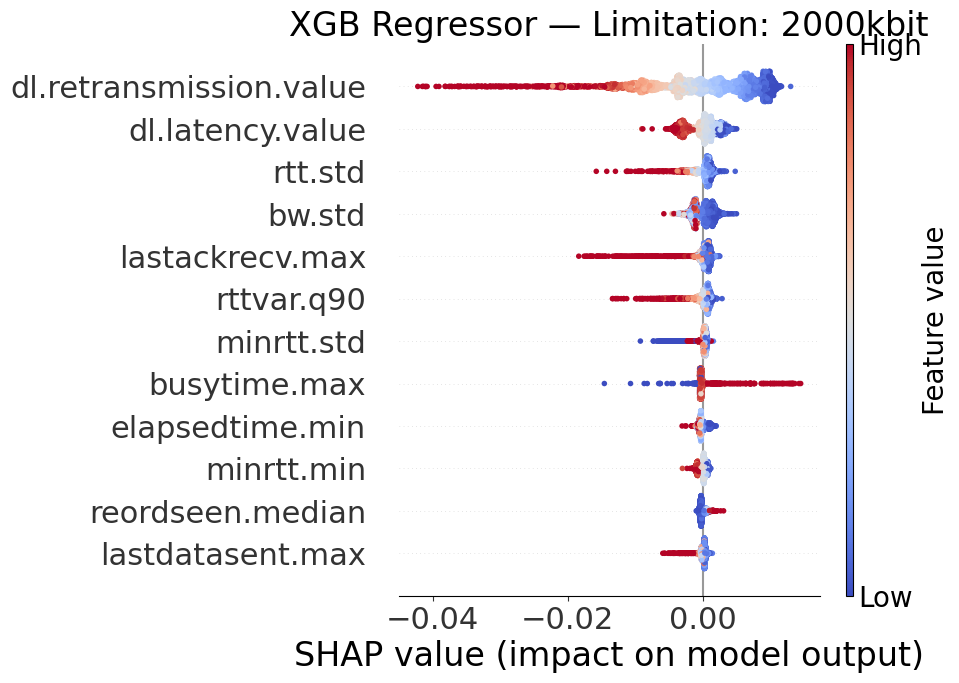

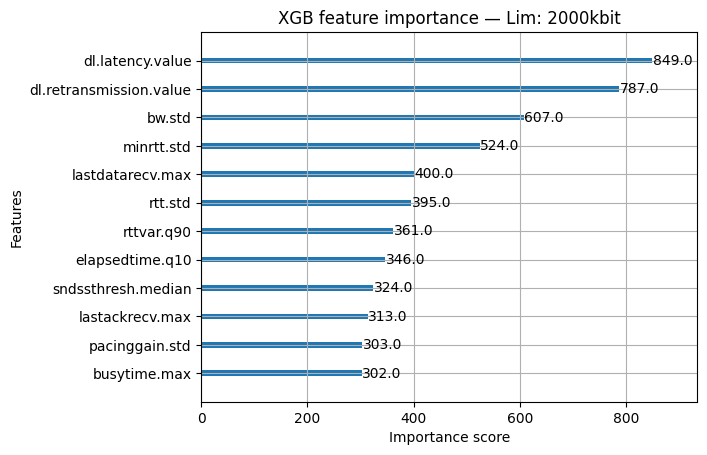

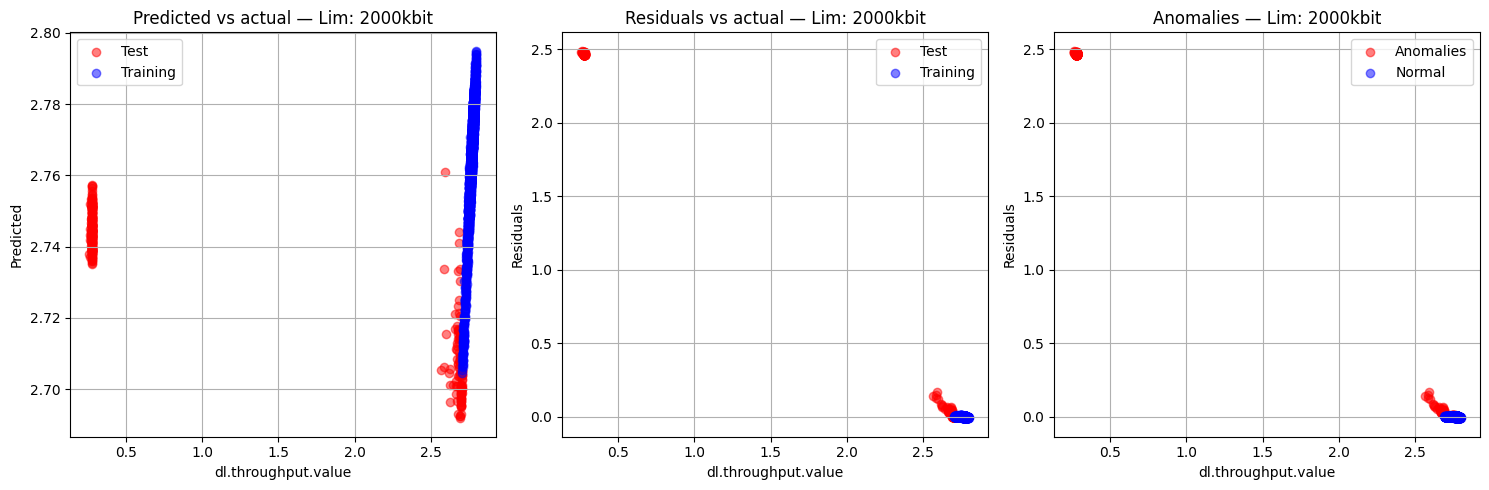


=== 5000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
dl.retransmission.value       0.007232
       dl.latency.value       0.001880
                rtt.std       0.001185
                 bw.std       0.001154
             rttvar.q90       0.000965
        lastackrecv.max       0.000960
             minrtt.std       0.000552
           busytime.max       0.000545
        elapsedtime.min       0.000465
             minrtt.min       0.000452


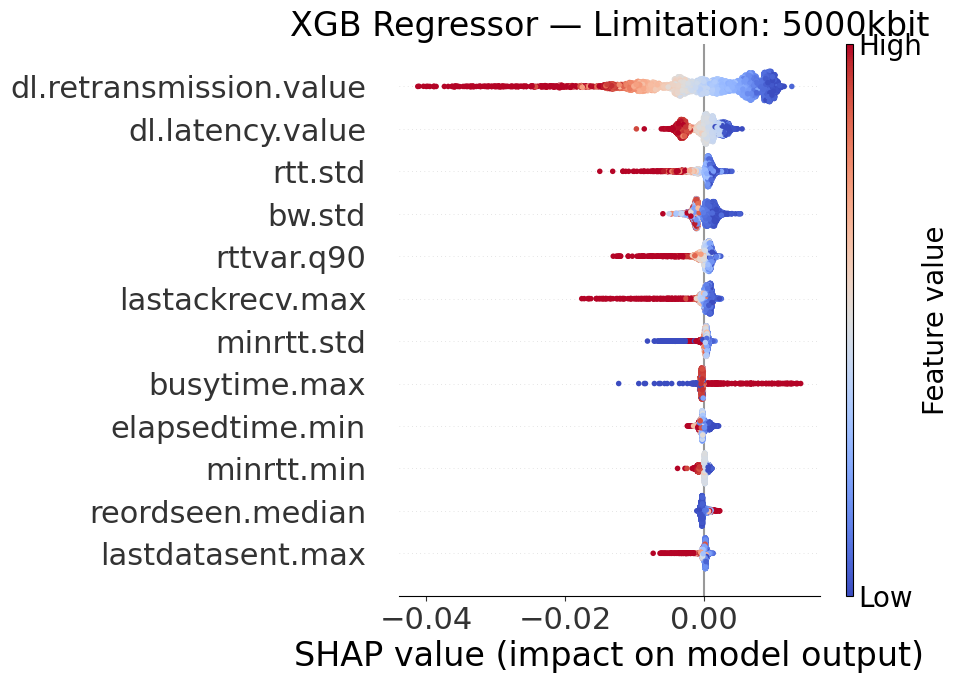

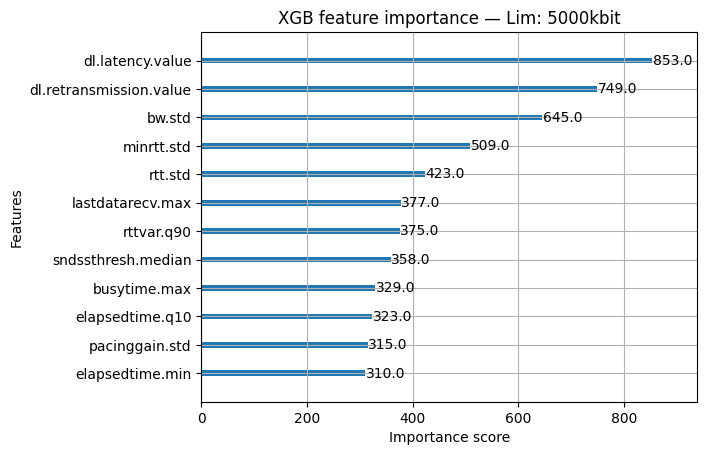

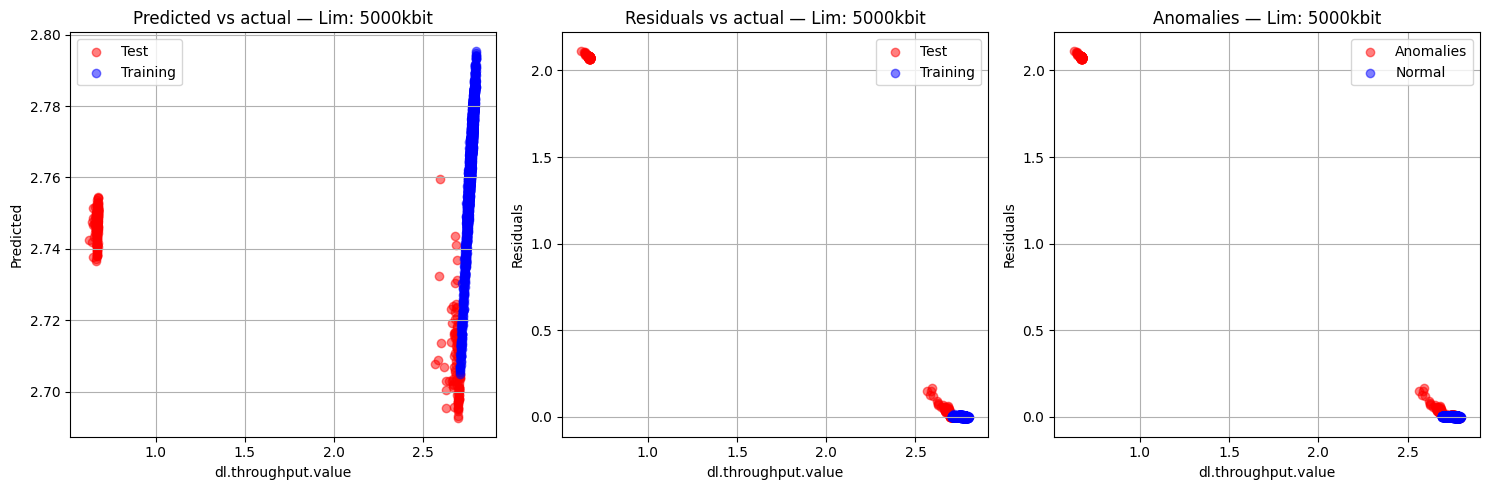


=== 10000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
dl.retransmission.value       0.007264
       dl.latency.value       0.001879
                 bw.std       0.001171
                rtt.std       0.001152
        lastackrecv.max       0.001022
             rttvar.q90       0.000944
        elapsedtime.min       0.000570
           busytime.max       0.000554
             minrtt.std       0.000548
             minrtt.min       0.000475


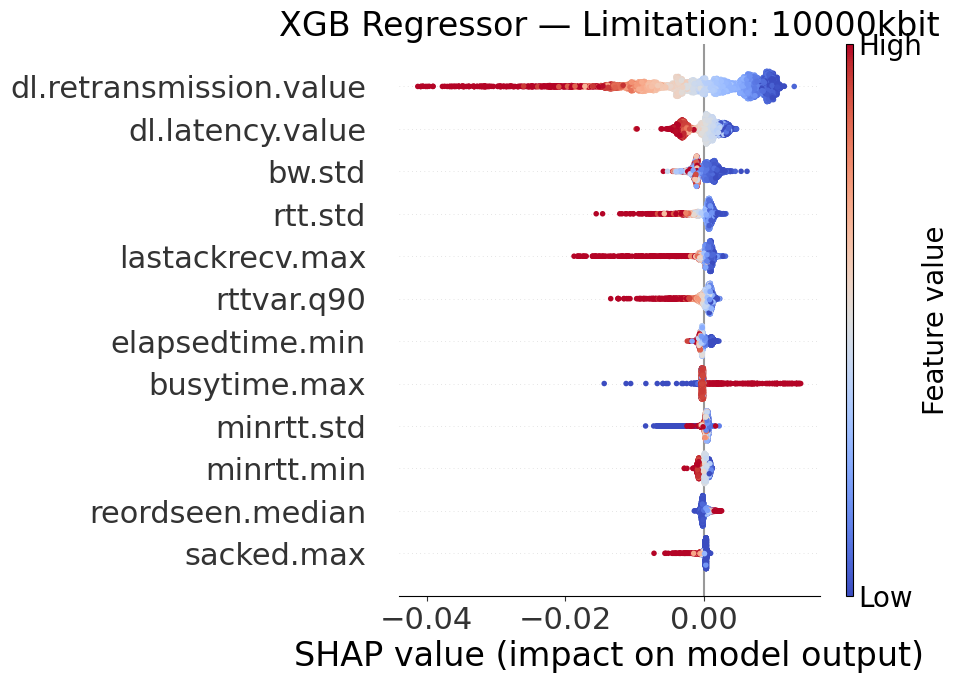

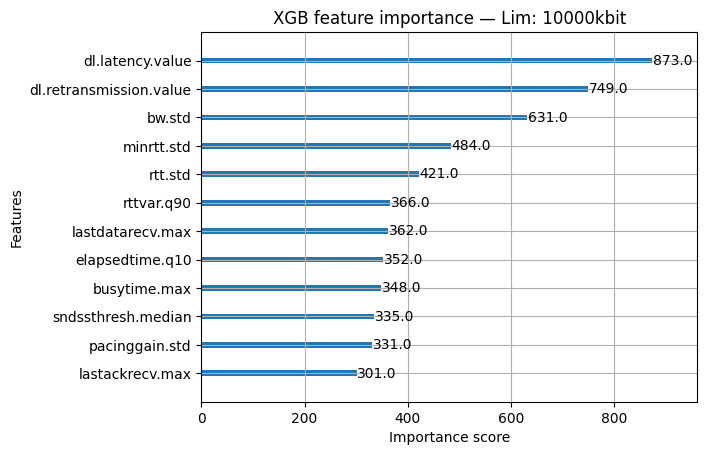

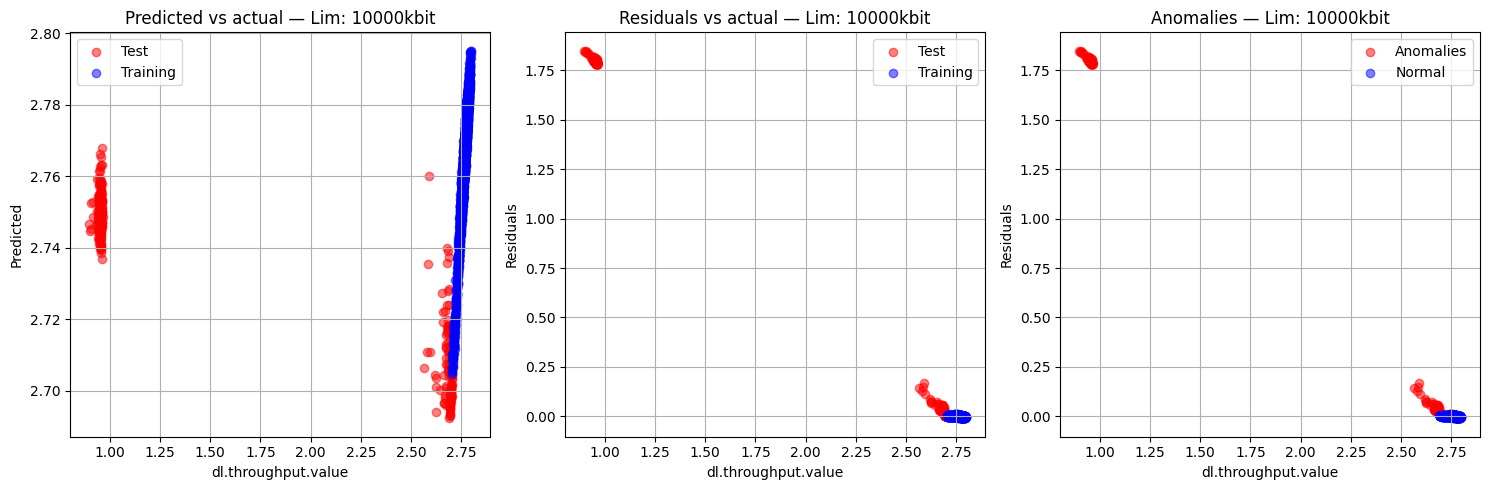


=== 20000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
dl.retransmission.value       0.007264
       dl.latency.value       0.001879
                 bw.std       0.001171
                rtt.std       0.001152
        lastackrecv.max       0.001022
             rttvar.q90       0.000944
        elapsedtime.min       0.000570
           busytime.max       0.000554
             minrtt.std       0.000548
             minrtt.min       0.000475


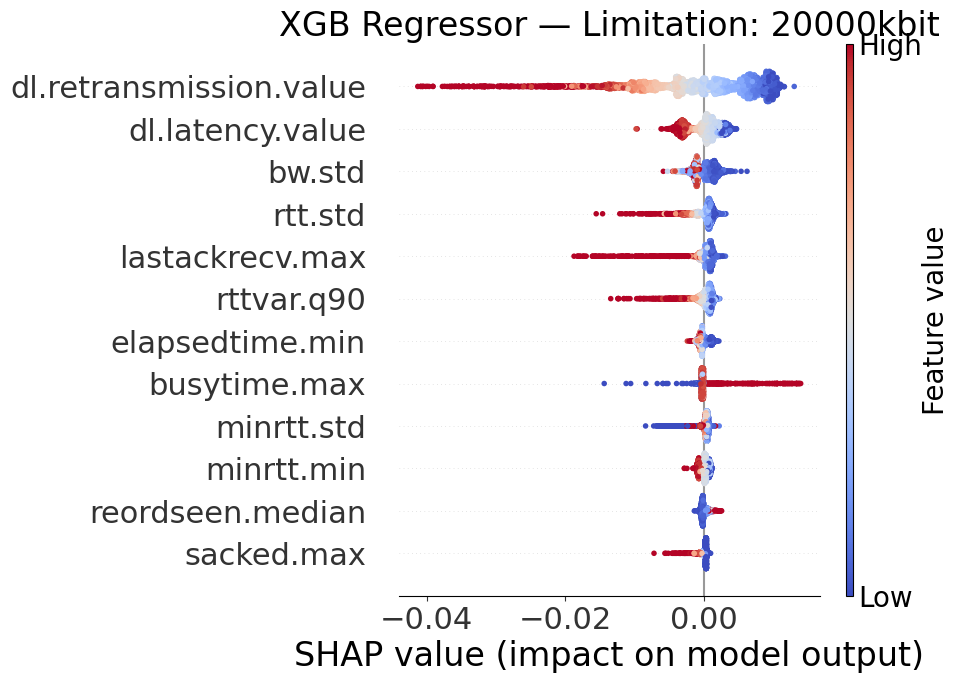

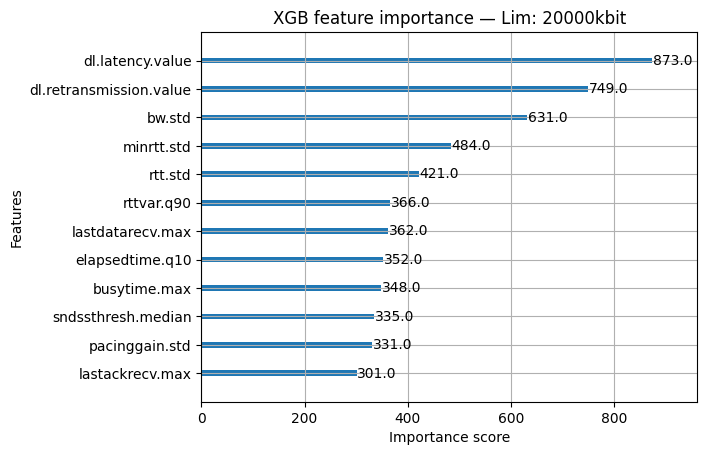

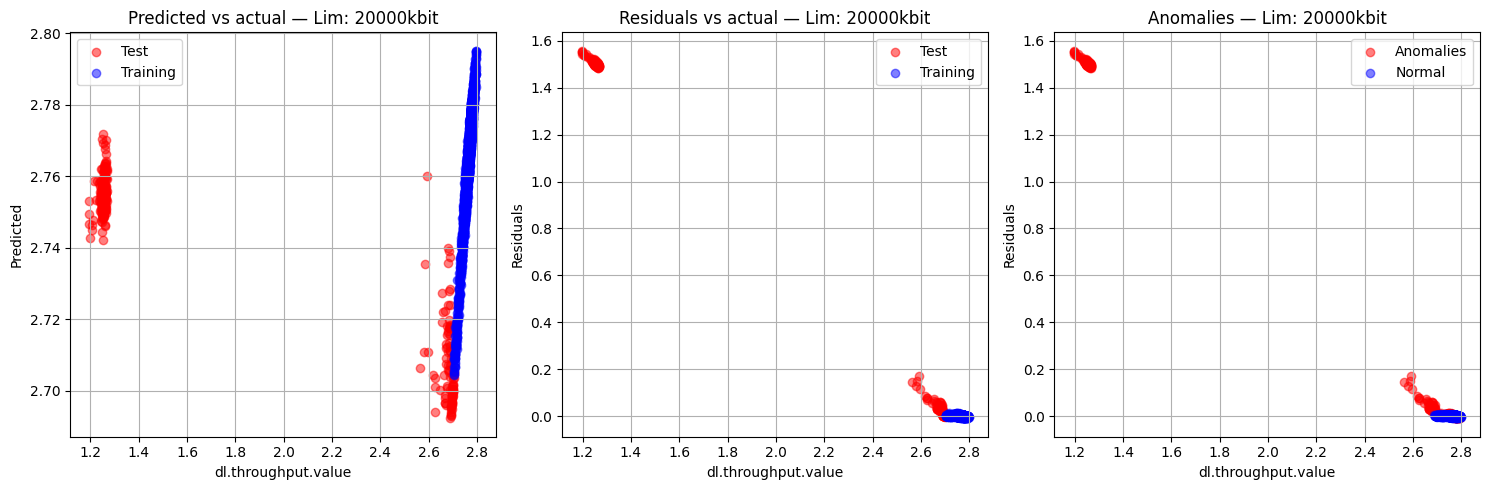


=== 50000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
dl.retransmission.value       0.007264
       dl.latency.value       0.001879
                 bw.std       0.001171
                rtt.std       0.001152
        lastackrecv.max       0.001022
             rttvar.q90       0.000944
        elapsedtime.min       0.000570
           busytime.max       0.000554
             minrtt.std       0.000548
             minrtt.min       0.000475


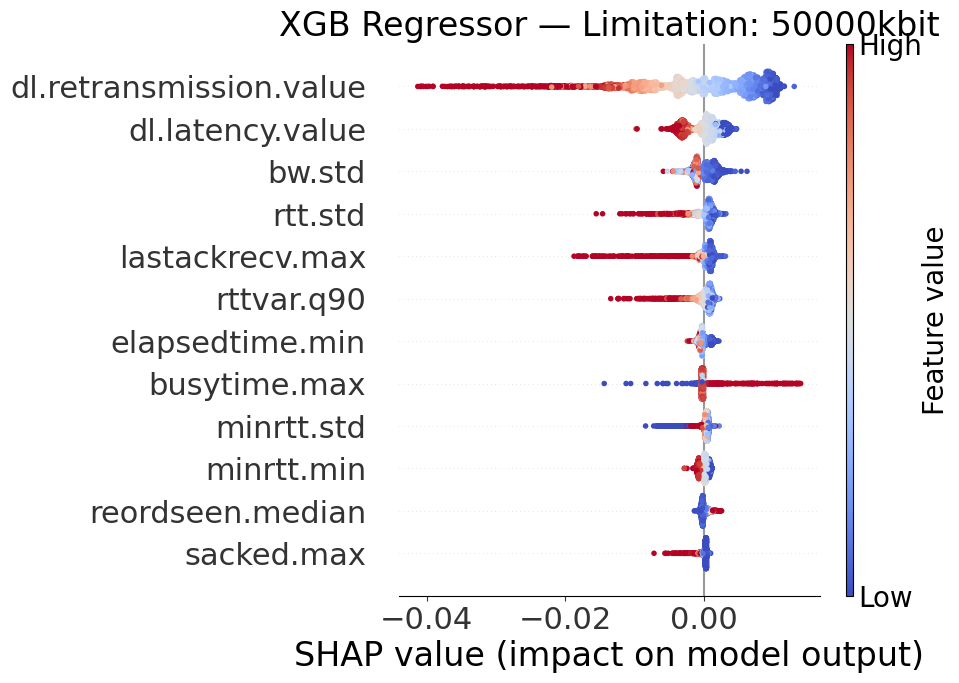

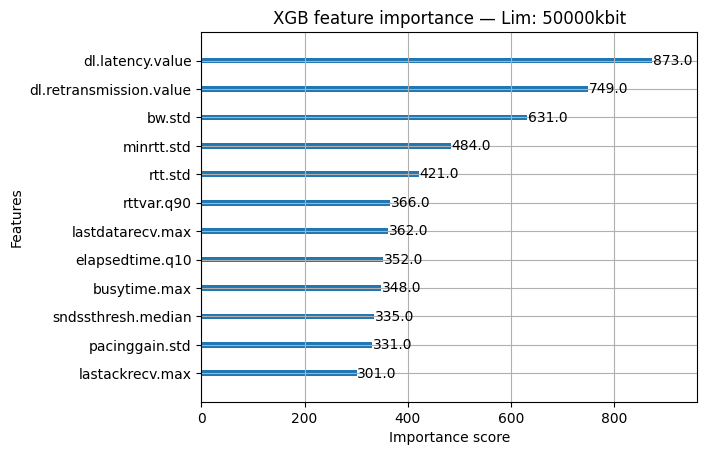

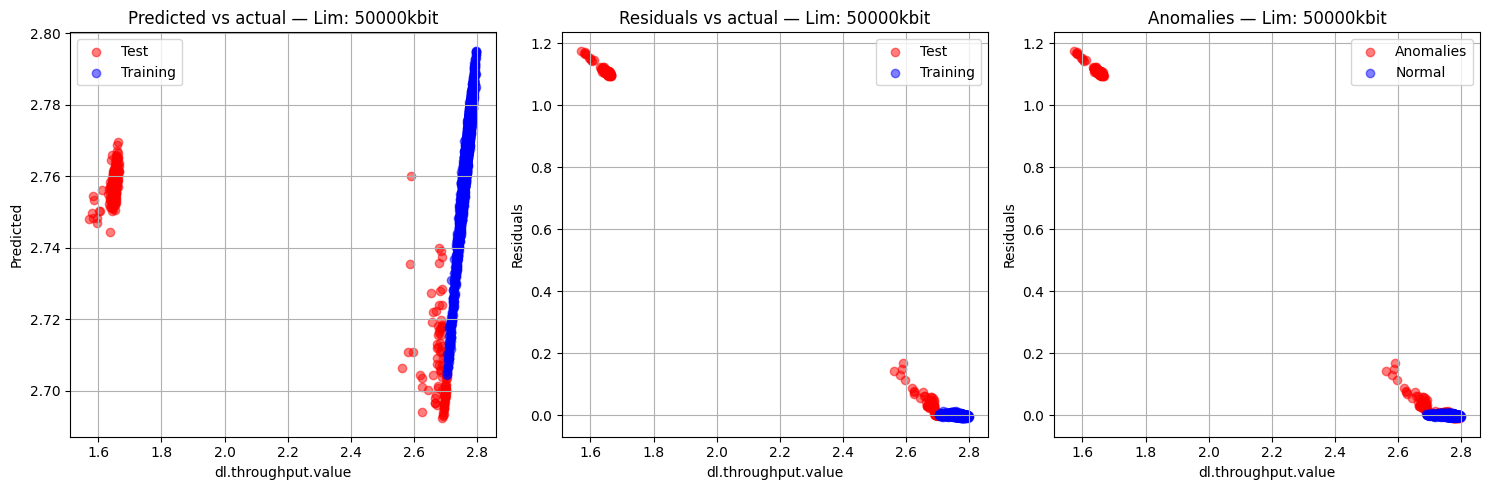

In [11]:
for lim in THROUGHPUT_LIMS:
    r = results[lim]

    shap_values  = compute_shap_values(r["model"], r["X_train"])
    shap_ranking = rank_features_by_mean_abs_shap(shap_values, r["X_train"].columns)

    results[lim].update({
        "shap_values":  shap_values,
        "shap_ranking": shap_ranking,
    })

    print(f"\n=== {lim} — top 10 features by mean |SHAP| ===")
    print(shap_ranking.head(10).to_string(index=False))

    plot_shap_summary(r["model"], r["X_train"], lim)
    plot_xgb_importance(r["model"], lim)
    plot_prediction_diagnostics(
        r["X_lim"], TARGET, r["y_predicted"], r["residuals"],
        r["outliers_mad"], r["anomalies"], lim,
    )

## 6. SAFE AI metrics

- **RGA** — rank-based accuracy of the normality model, robust to outliers
- **RGE** — rank-based feature contribution (complements SHAP)
- **RGR** — model robustness to feature perturbations

In [ ]:
from data_lab.safeai import safeai_summary

for lim in THROUGHPUT_LIMS:
    r = results[lim]

    print(f"\n=== {lim} ===")
    safeai_results = safeai_summary(
        y_true=r["X_lim"].loc[r["X_all"].index, TARGET],
        y_pred=r["y_predicted"],
        X_train=r["X_train"],
        X_test=r["X_all"],
        model=r["model"],
        top_n=10,
    )

    results[lim]["safeai"] = safeai_results
    
    
    


=== 1000kbit ===
Computing RGA ...
  RGA = 0.9364
Computing RGE ...
                feature      rge
dl.retransmission.value 0.084822
       dl.latency.value 0.008982
           busytime.max 0.005929
                 bw.std 0.004987
        elapsedtime.min 0.003230
     sndssthresh.median 0.002616
             minrtt.std 0.002500
                rtt.std 0.002126
        lastackrecv.max 0.002062
             rttvar.q90 0.001929
Computing RGR ...
          feature  rgr
 lastdatasent.min  1.0
     backoff.mean  1.0
rcvooopack.median  1.0
   rcvooopack.q10  1.0
   rcvooopack.q25  1.0
      backoff.q75  1.0
   rcvooopack.q75  1.0
      backoff.max  1.0
     cwndgain.min  1.0
  retransmits.q75  1.0

=== 2000kbit ===
Computing RGA ...
  RGA = 0.9223
Computing RGE ...
                feature      rge
dl.retransmission.value 0.090806
       dl.latency.value 0.009239
           busytime.max 0.005915
                 bw.std 0.005023
             minrtt.std 0.003151
     sndssthresh.median 0.0028

In [13]:
for lim in THROUGHPUT_LIMS:
    rgr_df = results[lim]["safeai"]["rgr"]
    print(f"\n=== {lim} — feature più sensibili (RGR basso) ===")
    print(rgr_df.tail(10).to_string(index=False))
    
for lim in THROUGHPUT_LIMS:
    rge = results[lim]["safeai"]["rge"].rename(columns={"rge": "rge"})
    rgr = results[lim]["safeai"]["rgr"].rename(columns={"rgr": "rgr"})
    merged = rge.merge(rgr, on="feature").sort_values("rge", ascending=False)
    print(f"\n=== {lim} — RGE vs RGR (top 15) ===")
    print(merged.head(15).to_string(index=False))


=== 1000kbit — feature più sensibili (RGR basso) ===
                feature      rgr
       lastdatasent.max 0.998823
        elapsedtime.min 0.998728
             rttvar.q90 0.997965
             minrtt.std 0.997841
        lastackrecv.max 0.995561
       dl.latency.value 0.994952
                rtt.std 0.993655
       lastdatarecv.max 0.992376
           busytime.max 0.983415
dl.retransmission.value 0.884401

=== 2000kbit — feature più sensibili (RGR basso) ===
                feature      rgr
        elapsedtime.min 0.998721
     sndssthresh.median 0.998215
             minrtt.std 0.997795
             rttvar.q90 0.997661
        lastackrecv.max 0.996056
       lastdatarecv.max 0.995338
       dl.latency.value 0.994900
                rtt.std 0.994015
           busytime.max 0.982585
dl.retransmission.value 0.909005

=== 5000kbit — feature più sensibili (RGR basso) ===
                feature      rgr
        elapsedtime.min 0.998831
             rttvar.q90 0.998015
       lastda

In [14]:
for lim in THROUGHPUT_LIMS:
    shap_top = results[lim]["shap_ranking"][["feature"]].head(10).assign(rank_shap=range(1,11))
    rge_top  = results[lim]["safeai"]["rge"][["feature"]].head(10).assign(rank_rge=range(1,11))
    merged   = shap_top.merge(rge_top, on="feature", how="outer").fillna("-")
    print(f"\n=== {lim} — SHAP vs RGE ranking ===")
    print(merged.to_string(index=False))


=== 1000kbit — SHAP vs RGE ranking ===
                feature rank_shap rank_rge
           busytime.max       8.0      3.0
                 bw.std       3.0      4.0
       dl.latency.value       2.0      2.0
dl.retransmission.value       1.0      1.0
        elapsedtime.min       7.0      5.0
        lastackrecv.max       5.0      9.0
             minrtt.min      10.0        -
             minrtt.std       9.0      7.0
                rtt.std       4.0      8.0
             rttvar.q90       6.0     10.0
     sndssthresh.median         -      6.0

=== 2000kbit — SHAP vs RGE ranking ===
                feature rank_shap rank_rge
           busytime.max       8.0      3.0
                 bw.std       4.0      4.0
       dl.latency.value       2.0      2.0
dl.retransmission.value       1.0      1.0
        elapsedtime.min       9.0      7.0
        lastackrecv.max       5.0     10.0
             minrtt.min      10.0        -
             minrtt.std       7.0      5.0
                r

# 6B Plotting

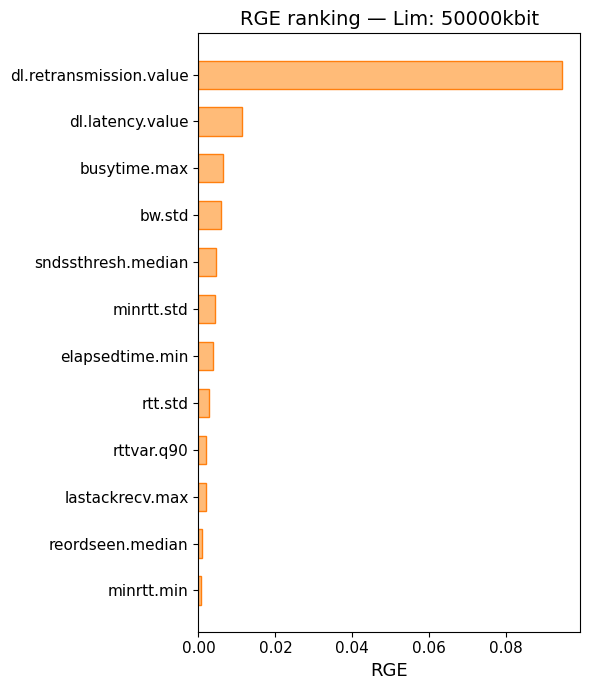

In [ ]:
from data_lab.plot_functions import plot_rge_ranking
plot_rge_ranking(safeai_results["rge"], lim)

In [ ]:
from data_lab.plot_functions import plot_rgr_ranking
plot_rgr_ranking(safeai_results["rgr"], lim)

In [ ]:
from data_lab.plot_functions import plot_rge_vs_rgr
plot_rge_vs_rgr(safeai_results["rge"], safeai_results["rgr"], lim)

In [ ]:
from data_lab.plot_functions import plot_shap_vs_rge
plot_shap_vs_rge(results[lim]["shap_ranking"], safeai_results["rge"], lim)

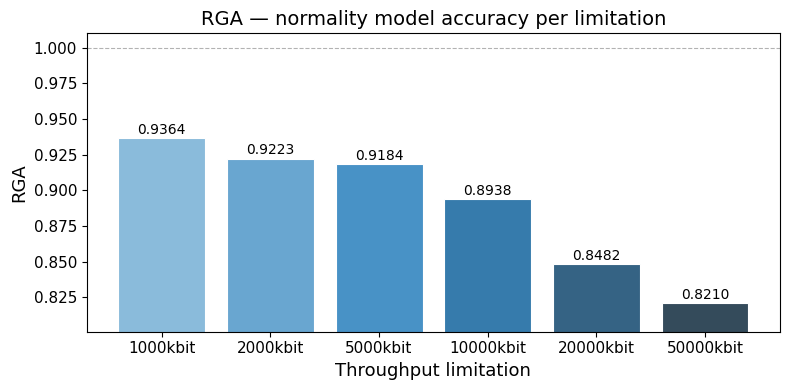

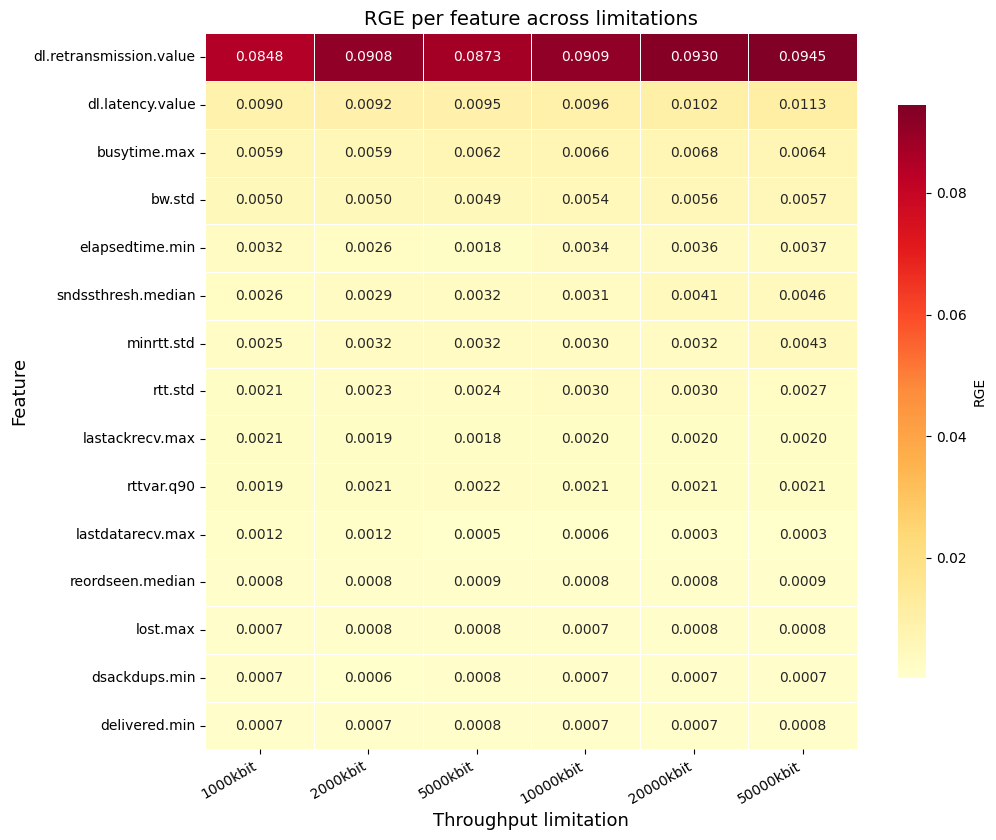

In [ ]:
from data_lab.plot_functions import plot_rga_by_limitation, plot_rge_heatmap

# RGA summary
rga_scores = {lim: results[lim]["safeai"]["rga"] for lim in THROUGHPUT_LIMS}
plot_rga_by_limitation(rga_scores)

# RGE heatmap cross-limitation
plot_rge_heatmap(results, THROUGHPUT_LIMS, top_n=15)

## 7. ROAD feature ranking

For each feature, fit 1-D GMMs with increasing number of clusters and compute
the Jaccard index between each cluster and the anomaly mask.
The ROAD index is the maximum Jaccard score — higher means stronger association with anomalies.

In [18]:
for lim in THROUGHPUT_LIMS:
    r     = results[lim]
    data1 = r["X_lim"].drop(columns=[TARGET])

    models, cls_mat = cluster_anomaly_support_optimal(
        data1, r["anomalies"], list(data1.columns), []
    )

    results[lim].update({
        "road_models": models,
        "cls_mat":     cls_mat,
        "data1":       data1,
    })

    print(f"\n=== {lim} ===")
    print(models.to_string(index=False))

    plot_road_ranking(
        models["road_index"].values,
        models["Attribute"].values,
    )


=== 1000kbit ===
       Attribute  road_index  Class_1  Class_2
lastdatasent.q90    0.655556 0.059379 0.940621
      rttvar.q75    0.652819 0.050607 0.949393
   rttvar.median    0.650602 0.048583 0.951417
dl.latency.value    0.644578 0.048133 0.951867

=== 2000kbit ===
          Attribute  road_index  Class_1  Class_2
   dl.latency.value    0.653251 0.047490 0.952510
lastdatasent.median    0.653251 0.047490 0.952510
         minrtt.min    0.653251 0.047490 0.952510
             bw.std    0.643963 0.046815 0.953185

=== 5000kbit ===
          Attribute  road_index  Class_1  Class_2
             bw.std    0.650307 0.047705 0.952295
   dl.latency.value    0.647416 0.048605 0.951395
         minrtt.min    0.647416 0.048605 0.951395
lastdatasent.median    0.631902 0.046355 0.953645

=== 10000kbit ===
       Attribute  road_index  Class_1  Class_2
dl.latency.value    0.643917 0.049460 0.950540
      minrtt.min    0.643917 0.049460 0.950540
          bw.std    0.625749 0.046987 0.953013
 las

## 8. Decision tree

Build an interpretable CART classifier to describe the feature intervals
associated with detected anomalies. The tree is pruned via cost-complexity
pruning with cross-validation to avoid overfitting.

In [ ]:
for lim in THROUGHPUT_LIMS:
    r      = results[lim]
    models = r["road_models"]
    cls_mat = r["cls_mat"]
    data1   = r["data1"]
    anomalies = r["anomalies"]

    attributes, att_ind = np.unique(models["Attribute"].values, return_index=True)
    cls_mat_unique      = cls_mat[:, att_ind]

    separator = ";"
    problem   = np.empty(cls_mat_unique.shape[0], dtype=object)
    for ii in range(cls_mat_unique.shape[0]):
        strings = []
        for jj in range(cls_mat_unique.shape[1]):
            if cls_mat_unique[ii, jj] == 1 and anomalies.iloc[ii]:
                strings.append(f"T{jj+1}P")
            elif cls_mat_unique[ii, jj] == 2 or (cls_mat_unique[ii, jj] == 1 and not anomalies.iloc[ii]):
                strings.append(f"T{jj+1}N")
        problem[ii] = separator.join(strings)

    X_dt            = data1.copy()
    X_dt["Problem"] = problem
    X_dt.loc[~X_dt["Problem"].str.contains("P"), "Problem"] = "Compliant"
    y_dt            = X_dt.pop("Problem")

    m3 = DTClassifier(DT_MAX_DEPTH, DT_MIN_SAMPLES, DT_CROSS_VAL)
    m3.fit(X_dt, y_dt)

    dot_data = tree.export_graphviz(
        m3.model,
        feature_names=np.array(X_dt.columns),
        class_names=m3.model.classes_,
        filled=True,
        rounded=True,
        out_file=None,
        precision=6,
        special_characters=True,
    )
    graph        = graphviz.Source(dot_data)
    graph.format = "png"
    output_path  = graph.render(filename=str(TREE_DIR / f"lim_{lim}"))
    print(f"{lim:12s} — decision tree saved to {output_path}")

In [ ]:
import pickle

from data_lab.config import OUT_DATASETS

with open(OUT_DATASETS / "results.pkl", "wb") as f:
    # salva solo quello che serve per il report
    # esclude oggetti pesanti come i modelli XGBoost
    report_data = {
        lim: {
            "comparison":    r["comparison"],
            "shap_ranking":  r["shap_ranking"],
            "anomalies":     r["anomalies"],
            "outliers_mad":  r["outliers_mad"],
            "outliers_real": r["outliers_real"],
            "safeai":        r["safeai"],
            "road_models":   r["road_models"],
        }
        for lim, r in results.items()
    }
    pickle.dump(report_data, f)
print("Results saved to output_datasets/results.pkl")